# Solar Radio Burst Data Demo

Run the cells below to generate example spectrograms from the synthetic burst generators and view them inline.

In [ ]:
#!pip install matplotlib
#!pip install scipy

In [ ]:
from pathlib import Path
import sys

repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "data_gen").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError("Could not find the repo root containing data_gen")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt

from data_gen.synthesizer import (
    generate_no_burst,
    generate_type_1,
    generate_type_2,
    generate_type_3,
    generate_type_4,
    generate_type_5,
)

print(f"Using repo root: {repo_root}")

Using repo root: c:\Git\solar-radio-classifier


c:\Git\solar-radio-classifier\data_gen\synthesizer.py:243: RuntimeWarning: invalid value encountered in power
  freqs = base_start_freq - base_drift * (progress ** curve_power)
c:\Git\solar-radio-classifier\data_gen\synthesizer.py:368: RuntimeWarning: invalid value encountered in power
  freqs = local_start_freq - total_drift * (progress ** curve_power)
c:\Git\solar-radio-classifier\data_gen\synthesizer.py:512: RuntimeWarning: invalid value encountered in power
  freqs3 = start_freq - drift3 * (progress3 ** np.random.uniform(0.6, 0.9))


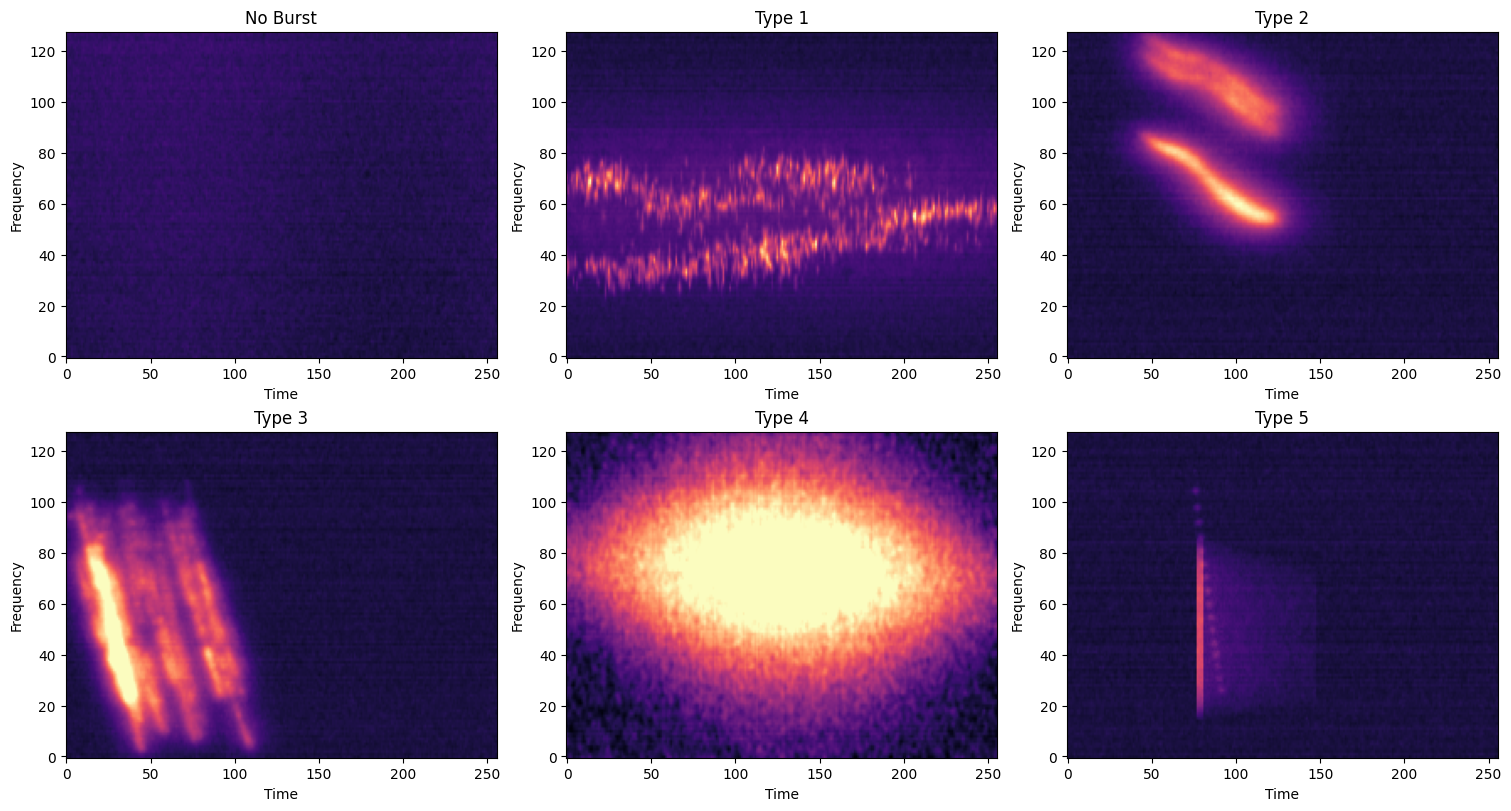

In [ ]:
generators = [
    ("No Burst", lambda: generate_no_burst(128, 256)),
    ("Type 1", lambda: generate_type_1(128, 256)),
    ("Type 2", lambda: generate_type_2(128, 256)),
    ("Type 3", lambda: generate_type_3(128, 256)),
    ("Type 4", lambda: generate_type_4(128, 256)),
    ("Type 5", lambda: generate_type_5(128, 256)),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
axes = axes.ravel()

for ax, (title, generator) in zip(axes, generators):
    image = generator()
    ax.imshow(image, aspect="auto", origin="lower", cmap="magma")
    ax.imshow(image, aspect="auto", origin="lower", cmap="magma", vmin=-0.2, vmax=1.5)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Frequency")

plt.show()

In [ ]:
# Verify the pipeline works by fetching one batch
batch_images, batch_labels = next(iter(train_loader))
print(f"✓ Successfully fetched a batch from S3:")
print(f"  - Batch images shape: {batch_images.shape}")
print(f"  - Batch labels: {batch_labels[:5].tolist()}... (showing first 5)")
print(f"\nYour training pipeline is ready! You can now use train_loader and test_loader in your model.")

In [ ]:
# Define transforms for preprocessing
train_transform = transforms.Compose([
    transforms.Resize((128, 256)),  # Match synthesizer output
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize grayscale
])

# Initialize datasets
train_dataset = S3Dataset(
    bucket_name=bucket_name,
    prefix='data/train/',
    access_key=aws_access_key,
    secret_key=aws_secret_key,
    transform=train_transform
)

test_dataset = S3Dataset(
    bucket_name=bucket_name,
    prefix='data/test/',
    access_key=aws_access_key,
    secret_key=aws_secret_key,
    transform=train_transform
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0  # Increase if you have multiple cores
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print(f"✓ DataLoaders created:")
print(f"  - Training batches: {len(train_loader)} (batch_size=32)")
print(f"  - Test batches: {len(test_loader)}")

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class S3Dataset(Dataset):
    """
    PyTorch Dataset that streams images directly from S3.
    Fetches images on-the-fly during training to save local storage.
    """
    
    def __init__(self, bucket_name, prefix, access_key, secret_key, transform=None):
        """
        Args:
            bucket_name: S3 bucket name
            prefix: S3 folder prefix (e.g., "data/train/")
            access_key: AWS access key ID
            secret_key: AWS secret access key
            transform: torchvision transforms to apply
        """
        self.s3 = boto3.client('s3',
                               aws_access_key_id=access_key,
                               aws_secret_access_key=secret_key)
        self.bucket_name = bucket_name
        self.prefix = prefix
        self.transform = transform
        
        # List all images in the S3 folder
        response = self.s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix)
        self.image_keys = []
        
        if 'Contents' in response:
            for obj in response['Contents']:
                key = obj['Key']
                if key.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_keys.append(key)
        
        # Extract label from filename
        self.labels = []
        for key in self.image_keys:
            # Parse burst type from filename (e.g., "data/train/type_1_0001.png" -> "type_1")
            filename = key.split('/')[-1]
            burst_type = filename.rsplit('_', 1)[0]  # Remove trailing number
            self.labels.append(burst_type)
        
        print(f"✓ Loaded {len(self.image_keys)} images from s3://{bucket_name}/{prefix}")
    
    def __len__(self):
        return len(self.image_keys)
    
    def __getitem__(self, idx):
        key = self.image_keys[idx]
        label_str = self.labels[idx]
        
        # Stream image from S3 into memory
        response = self.s3.get_object(Bucket=self.bucket_name, Key=key)
        img_data = response['Body'].read()
        image = Image.open(io.BytesIO(img_data)).convert('L')  # Grayscale
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        # Convert label string to numeric (for training)
        label_map = {
            "no_burst": 0,
            "type_1": 1,
            "type_2": 2,
            "type_3": 3,
            "type_4": 4,
            "type_5": 5,
        }
        label_idx = label_map.get(label_str, 0)
        
        return image, label_idx

print("✓ S3Dataset class defined and ready to use")

In [ ]:
def upload_spectrogram_to_s3(image_array, burst_type, image_id, split):
    """
    Convert numpy spectrogram to PIL Image and upload to S3.
    
    Args:
        image_array: 2D numpy array (spectrogram)
        burst_type: string name of burst type (e.g., "type_1")
        image_id: unique image number
        split: "train" or "test"
    """
    # Normalize to 0-255 for PNG
    img_normalized = ((image_array - image_array.min()) / (image_array.max() - image_array.min() + 1e-8) * 255).astype(np.uint8)
    
    # Convert to PIL Image
    pil_image = Image.fromarray(img_normalized, mode='L')
    
    # Save to bytes buffer
    img_buffer = io.BytesIO()
    pil_image.save(img_buffer, format='PNG')
    img_buffer.seek(0)
    
    # Upload to S3
    s3_key = f"data/{split}/{burst_type}_{image_id:04d}.png"
    s3_client.put_object(
        Bucket=bucket_name,
        Key=s3_key,
        Body=img_buffer.getvalue(),
        ContentType='image/png'
    )
    
    return s3_key

# Generate and upload images
uploaded_count = 0
for burst_type_name, generator_func in burst_types:
    print(f"\nGenerating {burst_type_name}...")
    
    # Training split
    for i in range(train_per_type):
        image = generator_func()
        s3_key = upload_spectrogram_to_s3(image, burst_type_name, i, "train")
        uploaded_count += 1
        if (i + 1) % 25 == 0:
            print(f"  ✓ {burst_type_name} (train): {i + 1}/{train_per_type}")
    
    # Test split
    for i in range(test_per_type):
        image = generator_func()
        s3_key = upload_spectrogram_to_s3(image, burst_type_name, i + train_per_type, "test")
        uploaded_count += 1
        if (i + 1) % 10 == 0:
            print(f"  ✓ {burst_type_name} (test): {i + 1}/{test_per_type}")

print(f"\n✓ Uploaded {uploaded_count} images to S3!")

In [ ]:
import io
from PIL import Image
import numpy as np

# Configuration
TOTAL_IMAGES = 1500
TRAIN_RATIO = 0.8
TRAIN_COUNT = int(TOTAL_IMAGES * TRAIN_RATIO)  # 1200
TEST_COUNT = TOTAL_IMAGES - TRAIN_COUNT  # 300

# Burst types and their generators
burst_types = [
    ("no_burst", generate_no_burst),
    ("type_1", generate_type_1),
    ("type_2", generate_type_2),
    ("type_3", generate_type_3),
    ("type_4", generate_type_4),
    ("type_5", generate_type_5),
]

# Distribute evenly across types
images_per_type = TOTAL_IMAGES // len(burst_types)  # 250 per type
train_per_type = int(images_per_type * TRAIN_RATIO)  # ~200 per type
test_per_type = images_per_type - train_per_type  # ~50 per type

print(f"Generating {TOTAL_IMAGES} images:")
print(f"  - Training: {TRAIN_COUNT}")
print(f"  - Testing: {TEST_COUNT}")
print(f"  - Per type: {images_per_type}")
print(f"    - Train per type: {train_per_type}")
print(f"    - Test per type: {test_per_type}")

In [ ]:
import os
import boto3
from dotenv import load_dotenv

# Load credentials from .env file (make sure .env is in .gitignore!)
load_dotenv()

aws_access_key = os.getenv('AWS_ACCESS_KEY_ID')
aws_secret_key = os.getenv('AWS_SECRET_ACCESS_KEY')
bucket_name = os.getenv('S3_BUCKET_NAME', 'your-bucket-name')

# Verify credentials are loaded
if not aws_access_key or not aws_secret_key:
    print("⚠️  AWS credentials not found. Set AWS_ACCESS_KEY_ID and AWS_SECRET_ACCESS_KEY in .env")
else:
    print(f"✓ AWS credentials loaded")
    print(f"✓ Using bucket: {bucket_name}")
    
# Initialize S3 client
s3_client = boto3.client('s3', 
                         aws_access_key_id=aws_access_key, 
                         aws_secret_access_key=aws_secret_key)

## AWS S3 Setup & Data Generation

This section generates 1,500 images, splits them into train/test sets, and uploads them to S3 for streaming during training.